In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_users = 10000

data = {
    'user_id': range(1, n_users + 1),
    'group': np.random.choice(['control', 'treatment'], n_users, p=[0.5, 0.5]),
    'device': np.random.choice(['mobile', 'desktop', 'tablet'], n_users, p=[0.6, 0.35, 0.05]),
    'age': np.random.normal(35, 10, n_users).astype(int),
    'session_duration': np.random.exponential(300, n_users),
}

for i in range(n_users):
    if data['group'][i] == 'treatment':
        data['session_duration'][i] *= 1.15
    if data['device'][i] == 'mobile':
        data['session_duration'][i] *= 0.8

df = pd.DataFrame(data)

conversion_prob = 1 / (1 + np.exp(-(data['session_duration'] / 300 - 1)))
df['converted'] = (np.random.random(n_users) < conversion_prob).astype(int)
df['clicks'] = np.random.poisson(lam=3 * (1 + 0.5 * (df['group'] == 'treatment')), size=n_users)

print("Dataset created successfully!")
print(f"Shape: {df.shape}")
print(df.head())
print(f"\nControl conversion rate: {df[df['group']=='control']['converted'].mean():.3f}")
print(f"Treatment conversion rate: {df[df['group']=='treatment']['converted'].mean():.3f}")

Dataset created successfully!
Shape: (10000, 7)
   user_id      group   device  age  session_duration  converted  clicks
0        1    control   mobile   26         93.827216          0       3
1        2  treatment   mobile   40         44.468545          0       3
2        3  treatment   mobile   48        301.472947          0       4
3        4  treatment  desktop   22         97.043148          0       4
4        5    control   mobile   52        146.252860          0       6

Control conversion rate: 0.466
Treatment conversion rate: 0.487


In [2]:
# Descriptive statistics
print("="*50)
print("DESCRIPTIVE STATISTICS BY GROUP")
print("="*50)
print(df.groupby('group').agg({
    'session_duration': ['mean', 'median', 'std', 'count'],
    'converted': ['mean', 'sum'],
    'clicks': ['mean', 'median']
}))

# Two-Sample T-Test
control = df[df['group']=='control']['session_duration']
treatment = df[df['group']=='treatment']['session_duration']
t_stat, p_value = stats.ttest_ind(treatment, control)
print("\n" + "="*50)
print("TWO-SAMPLE T-TEST: Session Duration")
print("="*50)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'}")

# Chi-Square Test
contingency_table = pd.crosstab(df['group'], df['converted'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print("\n" + "="*50)
print("CHI-SQUARE TEST: Conversion Rate")
print("="*50)
print(f"Chi-square: {chi2:.3f}")
print(f"P-value: {p_val:.5f}")
print(f"Significant: {'Yes' if p_val < 0.05 else 'No'}")

# Confidence Intervals
def calculate_ci(data, confidence=0.95):
    mean = np.mean(data)
    se = stats.sem(data)
    ci = stats.t.interval(confidence, len(data)-1, mean, se)
    return mean, ci

control_conv = df[df['group']=='control']['converted']
treatment_conv = df[df['group']=='treatment']['converted']
control_mean, control_ci = calculate_ci(control_conv)
treatment_mean, treatment_ci = calculate_ci(treatment_conv)

print("\n" + "="*50)
print("95% CONFIDENCE INTERVALS: Conversion Rate")
print("="*50)
print(f"Control: {control_mean:.4f} (CI: {control_ci[0]:.4f} - {control_ci[1]:.4f})")
print(f"Treatment: {treatment_mean:.4f} (CI: {treatment_ci[0]:.4f} - {treatment_ci[1]:.4f})")

# Effect Size (Cohen's d)
pooled_std = np.sqrt(((len(control)-1)*control.var() + (len(treatment)-1)*treatment.var()) / (len(control) + len(treatment) - 2))
cohens_d = (treatment.mean() - control.mean()) / pooled_std
print("\n" + "="*50)
print("EFFECT SIZE")
print("="*50)
print(f"Cohen's d: {cohens_d:.3f}")
print(f"Interpretation: {'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'} effect")

DESCRIPTIVE STATISTICS BY GROUP
          session_duration                               converted        \
                      mean      median         std count      mean   sum   
group                                                                      
control         264.751044  180.875927  268.582036  5076  0.465524  2363   
treatment       305.227135  207.635885  310.673691  4924  0.486799  2397   

             clicks         
               mean median  
group                       
control    2.977541    3.0  
treatment  4.513201    4.0  

TWO-SAMPLE T-TEST: Session Duration
T-statistic: 6.976
P-value: 0.00000
Significant: Yes

CHI-SQUARE TEST: Conversion Rate
Chi-square: 4.451
P-value: 0.03488
Significant: Yes

95% CONFIDENCE INTERVALS: Conversion Rate
Control: 0.4655 (CI: 0.4518 - 0.4793)
Treatment: 0.4868 (CI: 0.4728 - 0.5008)

EFFECT SIZE
Cohen's d: 0.140
Interpretation: Small effect


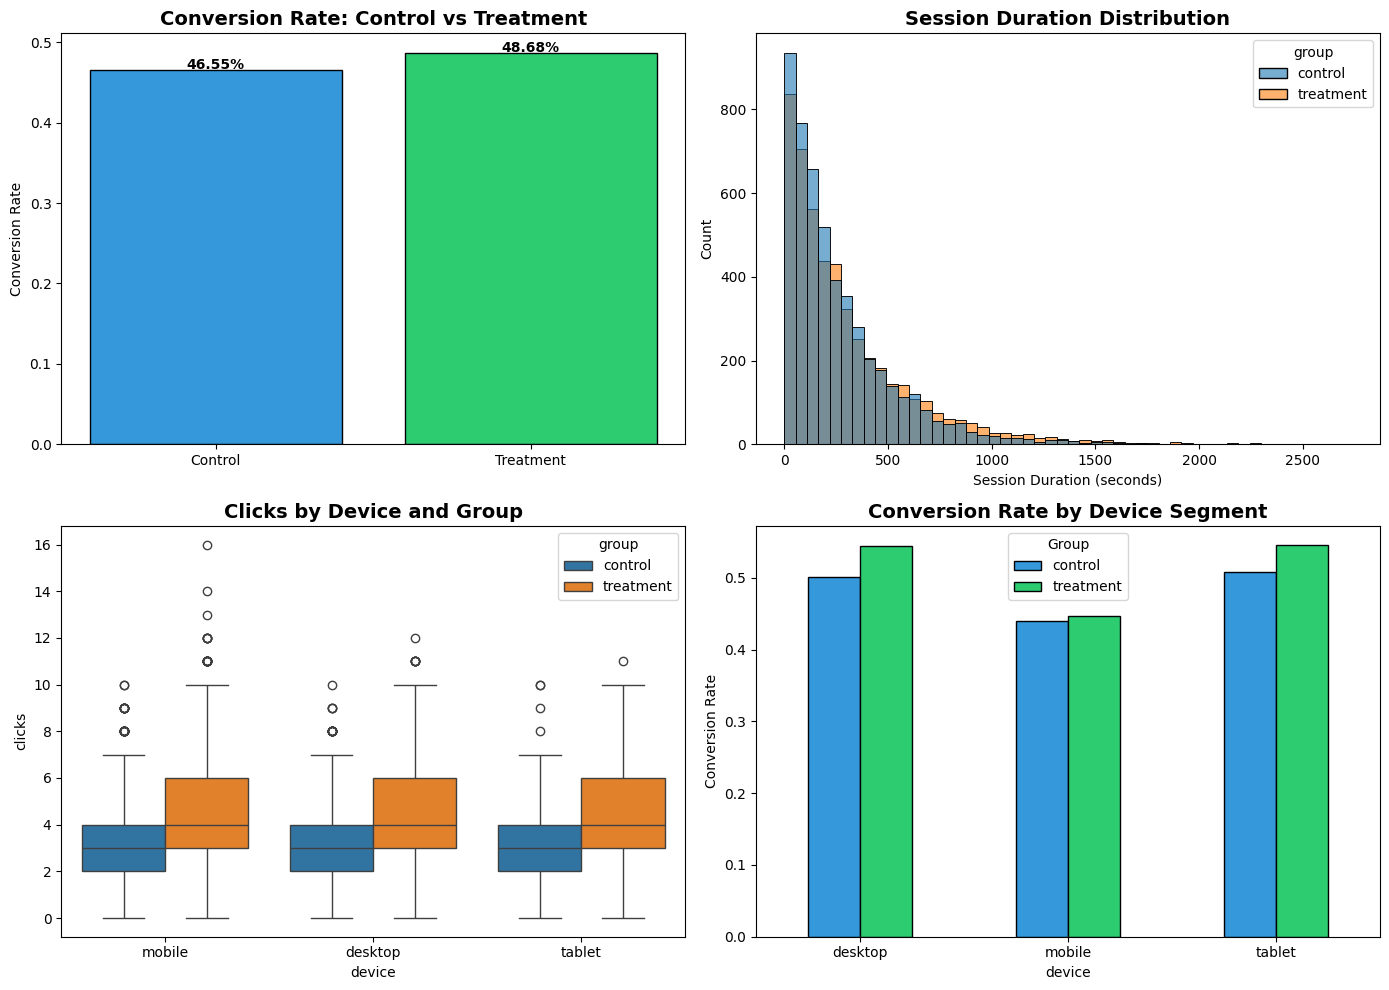

Visualizations saved!


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Conversion rate comparison
ax1 = axes[0, 0]
groups = ['Control', 'Treatment']
conv_rates = [control_conv.mean(), treatment_conv.mean()]
colors = ['#3498db', '#2ecc71']
bars = ax1.bar(groups, conv_rates, color=colors, edgecolor='black')
ax1.set_title('Conversion Rate: Control vs Treatment', fontsize=14, fontweight='bold')
ax1.set_ylabel('Conversion Rate')
for bar, rate in zip(bars, conv_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{rate:.2%}', ha='center', fontweight='bold')

# 2. Session duration distribution
ax2 = axes[0, 1]
sns.histplot(data=df, x='session_duration', hue='group', bins=50, ax=ax2, alpha=0.6)
ax2.set_title('Session Duration Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Session Duration (seconds)')

# 3. Clicks by device
ax3 = axes[1, 0]
sns.boxplot(data=df, x='device', y='clicks', hue='group', ax=ax3)
ax3.set_title('Clicks by Device and Group', fontsize=14, fontweight='bold')

# 4. Segment analysis - conversion by device
ax4 = axes[1, 1]
segment_data = df.groupby(['device', 'group'])['converted'].mean().unstack()
segment_data.plot(kind='bar', ax=ax4, color=['#3498db', '#2ecc71'], edgecolor='black')
ax4.set_title('Conversion Rate by Device Segment', fontsize=14, fontweight='bold')
ax4.set_ylabel('Conversion Rate')
ax4.legend(title='Group')
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('ab_test_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Visualizations saved!")

In [4]:
# Mann-Whitney U Test (non-parametric check)
u_stat_duration, p_duration_mw = stats.mannwhitneyu(treatment, control, alternative='two-sided')
print("=" * 50)
print("MANN-WHITNEY U TEST: Session Duration")
print("=" * 50)
print(f"U-statistic: {u_stat_duration:.1f}")
print(f"P-value: {p_duration_mw:.6f}")
print(f"Significant: {'Yes' if p_duration_mw < 0.05 else 'No'}")

control_clicks = df[df['group']=='control']['clicks']
treatment_clicks = df[df['group']=='treatment']['clicks']
u_stat_clicks, p_clicks_mw = stats.mannwhitneyu(treatment_clicks, control_clicks, alternative='two-sided')
print("\n" + "=" * 50)
print("MANN-WHITNEY U TEST: Clicks")
print("=" * 50)
print(f"U-statistic: {u_stat_clicks:.1f}")
print(f"P-value: {p_clicks_mw:.6f}")
print(f"Significant: {'Yes' if p_clicks_mw < 0.05 else 'No'}")

# Segment analysis: conversion rate by device
print("\n" + "=" * 50)
print("SEGMENT ANALYSIS: Conversion Rate by Device")
print("=" * 50)
segment_summary = df.groupby(['device', 'group'])['converted'].agg(['mean', 'count'])
print(segment_summary)


MANN-WHITNEY U TEST: Session Duration
U-statistic: 13288163.0
P-value: 0.000000
Significant: Yes

MANN-WHITNEY U TEST: Clicks
U-statistic: 17791972.0
P-value: 0.000000
Significant: Yes

SEGMENT ANALYSIS: Conversion Rate by Device
                       mean  count
device  group                     
desktop control    0.501680   1786
        treatment  0.544725   1744
mobile  control    0.440397   3020
        treatment  0.447179   2925
tablet  control    0.507407    270
        treatment  0.545098    255
